In [ ]:
from tensorflow.keras.datasets import mnist # MNIST 데이터 불러오기

불러온 이미지 데이터를 X로, 이 이미지에 0~9를 붙인 이름표를 y로 구분  
또한, 7만 개 중 학습에 사용될 부분은 train, 테스트에 사용될 부분은 test  
  
  
학습에 사용될 부분: X_train, y_train  
테스트에 사용될 부분: X_test, y_test

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
print("학습셋 이미지 수: %d개" % (X_train.shape[0]))
print("테스트셋 이미지 수: %d개" % (X_test.shape[0]))

학습셋 이미지 수: 60000개
테스트셋 이미지 수: 10000개


imshow() 함수를 이용해 이미지를 출력한다. 이미지는 cmap:'Greys' 옵션을 지정해 흑백으로 출력한다.

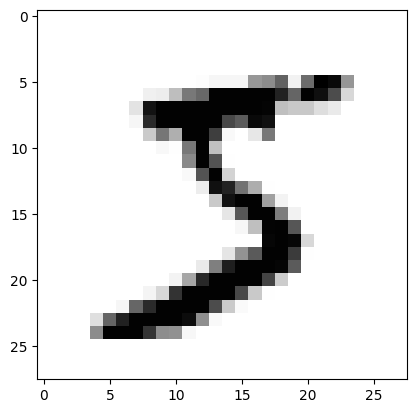

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='Greys')
plt.show()

In [ ]:
import sys

for x in X_train[0]:
    for i in x:
        sys.stdout.write("%-3s" % i)
    sys.stdout.write('\n')

0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  3  18 18 18 12613617526 1662552471270  0  0  0  
0  0  0  0  0  0  0  0  30 36 94 15417025325325325325322517225324219564 0  0  0  0  
0  0  0  0  0  0  0  49 23825325325325325325325325325193 82 82 56 39 0  0  0  0  0  
0  0  0  0  0  0  0  18 2192532532532532531981822472410  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  80 15610725325320511 0  43 1540  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  14 1  15425390 0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  1392531902  0  0  0  0  0  0  0 

이렇게 이미지는 다시 숫자의 집합으로 바뀌어 학습셋으로 사용된다.

가로 28, 세로 28의 2차원 배열을 784개의 1차원 배열로 바꾸어 주어야한다. 이를 위해 reshape() 함수를 사용한다.  
reshape(총 샘플 수, 1차원 속성의 개수) 형식으로 지정한다. 총 샘플 수는 앞서 X_train.shape[0]을 이용하고, 1차원 속성의 개수는 784개이다.

In [ ]:
X_train = X_train.reshape(X_train.shape[0], 784)

케라스는 데이터를 0에서 1 사이의 값으로 변환한 후 구동할 때 최적의 성능을 보인다. 데이터의 폭이 클 때 적절한 값으로 분산의 정도를 바꾸는 과정을 데이터 정규화(normalization)라고 한다.  
astype() 함수를 이용해 실수형으로 바꾼 후 255로 나눈다.

In [ ]:
X_train = X_train.astype('float64')
X_train = X_train / 255

In [ ]:
X_test = X_test.reshape(X_test.shape[0], 784).astype('float64') /  255

In [33]:
print("class: %d" % (y_train[0]))

class: 5


딥러닝의 분류 문제를 해결하려면 원-핫 인코딩 방식을 적용해야 한다. 즉, 0~9의 정수형 값을 갖는 현재 형태에서 0 또는 1로만 이루어진 벡터로 값을 수정한다.  
이를 가능하게 해 주는 함수가 바로 np_utils.to_categorical()함수이다. to_categorical(클래스, 클래스의 개수) 형식으로 지정한다.

In [35]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [36]:
print(y_train[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


실습| MNIST 손글씨 인식하기: 데이터 전처리

학습셋 이미지 수: 60000개
테스트셋 이미지 수: 60000개


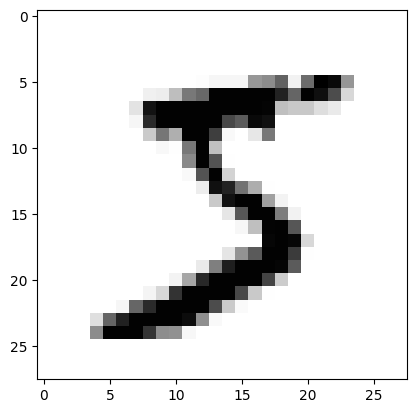

0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  3  18 18 18 12613617526 1662552471270  0  0  0  
0  0  0  0  0  0  0  0  30 36 94 15417025325325325325322517225324219564 0  0  0  0  
0  0  0  0  0  0  0  49 23825325325325325325325325325193 82 82 56 39 0  0  0  0  0  
0  0  0  0  0  0  0  18 2192532532532532531981822472410  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  80 15610725325320511 0  43 1540  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  14 1  15425390 0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  1392531902  0  0  0  0  0  0  0 

In [41]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import sys

# MNIST 데이터셋을 불러와 학습셋과 테스트셋으로 저장한다.
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 학습셋과 테스트셋이 각각 몇 개의 이미지로 되어 있는지 확인한다.
print("학습셋 이미지 수: %d개" % (X_train.shape[0]))
print("테스트셋 이미지 수: %d개" % (X_train.shape[0]))

# 첫 번째 이미지를 확인해본다.
plt.imshow(X_train[0], cmap="Greys")
plt.show()

# 이미지가 인식되는 원리를 알아본다.
for x in X_train[0]:
    for i in x:
        sys.stdout.write("%-3s" % i)
    sys.stdout.write('\n')

# 차원 변환 과정을 실습한다.
X_train = X_train.reshape(X_train.shape[0], 784)
X_train = X_train.astype('float64')
X_train = X_train / 255

X_test = X_test.reshape(X_test.shape[0], 784).astype('float64') / 255

# 클래스 값을 확인해본다.
print("class: %d" % (y_train[0]))

# 바이너리화 과정을 실습해본다.
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(y_train[0])